# 06 — Observer frame vs. velocity frame

**Exploratory twin of `scripts/plot_velocity_frame_comparison.py`.** Both this
notebook and that script call the same stage functions from
`dvcorr.pipeline.velocity_frame_comparison` — the single source of truth for
this pipeline (CLAUDE.md: notebooks are exploration only, "diagnostics that
import the real modules, never reimplement them"). Every code cell below just
calls one stage in sequence.

## The question

Notebook 05 measured the **observer-frame** dipole ζ₁ (Nusser 2017 eq. 23–24).
Each velocity object α sits at the center of its shells, axed on the part of
its motion the observer can actually see, and weighted by the corresponding
**radial speed**:

$$\hat z_\alpha^{\,\rm obs} = \mathrm{sign}(u_\alpha)\,\hat n_{V,\alpha},
  \qquad \text{scalar} = |u_\alpha|,
  \qquad u_\alpha = \mathbf v_\alpha \cdot \hat n_{V,\alpha}$$

This notebook adds the **velocity-frame** variant, which removes the observer
from the statistic entirely. It is the *same construction* with the full 3-D
velocity in place of its radial projection:

$$\hat z_\alpha^{\,\rm vel} = \frac{\mathbf v_\alpha}{|\mathbf v_\alpha|},
  \qquad \text{scalar} = |\mathbf v_\alpha|$$

Both axes follow the object's **motion** (`conventions.VELOCITY_AXIS_CONVENTION`);
both weights are **speeds**. The frames differ only in full 3-vector vs. radial
projection, which is exactly what makes them comparable.

The observer survives only in two places, neither of which touches the
statistic: the `core_center_mask` candidate cut (pure geometry, deliberately
**the identical function for both frames**) and the diagnostic angle δ_α below.

**Comparing the two quantifies what is lost by having a finite-distance
observer restricted to radial velocities.** In the ideal spherical-infall,
distant-observer limit the two coincide — including for an *inbound* flow,
where both axes point back toward the observer together; their divergence
measures projection geometry plus the center's own bulk motion.

## Reading an amplitude gap — three contributors, not one

A difference between the two curves is **not** purely axis rotation. In
decreasing order of size on the toy infall configuration:

1. **Self-alignment / no ⟨cos²θ⟩ = 1/3 dilution.** The velocity frame takes its
   *whole* axis from the object that supplies the scalar, so the alignment is
   not averaged down over the shell. The observer frame takes only a **sign**
   from the velocity and its **line** from the center's position, and that
   remaining positional dependence is the dilution. Worth a factor ≈ 3 on the
   sign-gate toy.
2. **|v| vs. |u|.** Both scalars are positive-definite, but |u| ≤ |v| always —
   the radial projection is a strictly smaller number.
3. **Axis rotation** proper — the transverse velocity component, invisible to
   the observer frame.

Do not attribute the whole gap to (3).

## Sign

Both frames are **positive** for coherent infall. Mass flows toward
overdensities, so the density excess lies *ahead* of the flow (velocity frame),
and ζ_ℓ = (−1)^ℓ ξ_Tu,ℓ flips hard rule 2's negative group-centered ξ_Tu,1 to a
positive ζ₁ (observer frame). A **negative** dipole from either frame on an
infall configuration is an orientation bug, not a result — see the sign gate in
`tests/test_velocity_frame_dipole.py`.

In [1]:
%matplotlib inline

import numpy as np

from dvcorr import conventions
from dvcorr.config import PathsConfig
from dvcorr.estimators.shell_dipole import expected_shell_occupancy
from dvcorr.pipeline.velocity_centered import global_number_density, load_and_carve, draw_candidates
from dvcorr.pipeline.velocity_frame_comparison import (
    ComparisonRunConfig,
    select_shared_centers,
    run_both_frames,
    normalize_comparison,
    make_comparison_figure,
    make_angle_diagnostic_figure,
)

print("observer (box center):", conventions.OBSERVER_POSITION)
print("BOX_SIZE            :", conventions.BOX_SIZE, " h^-1 Mpc")
print("MAX_ANALYSIS_RADIUS :", conventions.MAX_ANALYSIS_RADIUS, " h^-1 Mpc")

observer (box center): [500. 500. 500.]
BOX_SIZE            : 1000.0  h^-1 Mpc
MAX_ANALYSIS_RADIUS : 500.0  h^-1 Mpc


## Parameters

`ComparisonRunConfig` extends notebook 05's `RunConfig` with the comparison-only
knobs (the two output filenames and `axis_null_seed`); everything else —
`sub_volume_radius`, the composed `cfg.shells` binning, `n_candidate_centers`,
the seeds — is inherited unchanged, so this run is directly comparable to 05's.

`min_center_speed` lives on the **base** `RunConfig` because it filters the
*shared* center set, not one frame's: a halo with |v_α| below it has no
well-defined flow direction v̂_α, so it is dropped from **both** frames at the
orchestration level, never inside an estimator.

In [2]:
cfg = ComparisonRunConfig()
paths = PathsConfig()
observer = np.asarray(conventions.OBSERVER_POSITION, dtype=float)

print(cfg)
print()
print("shell_edges      :", cfg.shells.shell_edges)
print("min_center_speed :", cfg.min_center_speed, "km/s")
print("axis_null_seed   :", cfg.axis_null_seed)

ComparisonRunConfig(sub_volume_radius=300.0, shells=ShellConfig(min_radius=1.0, max_radius=64.0, radii_step=10.0, sigma_star=250.0, spacing='log', n_bins=12), n_candidate_centers=4000, seed=42, shuffle_seed=43, output_name='velocity_centered_dipole.png', dpi=150, min_center_speed=1.0, comparison_output_name='velocity_frame_comparison.png', angle_diagnostic_output_name='velocity_frame_angle_diagnostic.png', axis_null_seed=44)

shell_edges      : [ 1.          1.41421356  2.          2.82842712  4.          5.65685425
  8.         11.3137085  16.         22.627417   32.         45.254834
 64.        ]
min_center_speed : 1.0 km/s
axis_null_seed   : 44


## 1 — Load and carve

Identical stage to notebook 05 — `load_and_carve` is *imported from*
`dvcorr.pipeline.velocity_centered`, not duplicated here. Loads only
`POSITION_COLUMNS + VELOCITY_COLUMNS` from the ~4M-row MDPL2 catalog, then keeps
halos within `cfg.sub_volume_radius` of the observer. Plain Euclidean distance
IS the minimum image here — the sub-volume sits well inside the box, clear of
the periodic faces — so no wrapping is needed (hard rule 3 is discharged by the
carve, not by the geometry primitives).

In [3]:
pos, vel = load_and_carve(cfg, paths)

loading /home/ofeke2000/Cross-correlating-Tempel-SDSS-groups-with-Cosmicflows-4-peculiar-velocities/data/mdpl2_rockstar_125_pid-1_mvir12.csv (columns: ['x', 'y', 'z', 'vx', 'vy', 'vz']) ...


loaded 4093751 halos


carved 464764 of 4093751 halos within sub_volume_radius = 300.0 h^-1 Mpc (11.35%)


## 2 — Draw candidate centers

A seeded subsample of the carved halos, as *candidate* centers. Two cuts still
stand between these and the measured center set — the core cut and the speed
floor — and the next cell applies both, once, for both frames.

In [4]:
s_candidates, v_candidates = draw_candidates(cfg, pos, vel)
print("candidate centers:", s_candidates.shape[0])

candidate centers: 4000


## 3 — Select the SHARED center set

This is the cell that makes the comparison a fair one. `select_shared_centers`
applies, **once**:

1. `core_center_mask` — the same function the observer-frame estimator uses
   internally, with `core_margin = r_max`, so a surviving center's full shell
   fits inside the carved sub-volume (suppressing the boundary-truncation bias);
2. the `min_center_speed` floor — centers whose flow direction is ill-defined.

Both frames then receive the **identical** `s_centers` / `v_centers` arrays, so
the only difference between the two measurements is the axis and the velocity
scalar. `n_dropped_slow` is returned as a field, not merely printed.

In [5]:
centers = select_shared_centers(cfg, s_candidates, v_candidates, observer)

print()
print("n_candidates   :", centers.n_candidates)
print("n_core         :", centers.n_core, " (survived the core cut)")
print("n_dropped_slow :", centers.n_dropped_slow, f" (|v| < {cfg.min_center_speed} km/s)")
print("n_centers      :", centers.n_centers, " <- used by BOTH frames")

speeds = np.linalg.norm(centers.v_centers, axis=1)
print()
print(f"center speeds  : min={speeds.min():.1f}  median={np.median(speeds):.1f}  max={speeds.max():.1f} km/s")

n_candidates = 4000 -> core cut (core_margin = 64.0) -> n_core = 1933 (48.3% survive) -> speed floor (min_center_speed = 1.0 km/s) -> n_centers = 1933 (0 dropped as too slow)

n_candidates   : 4000
n_core         : 1933  (survived the core cut)
n_dropped_slow : 0  (|v| < 1.0 km/s)
n_centers      : 1933  <- used by BOTH frames

center speeds  : min=28.3  median=469.7  max=1928.1 km/s


## 4 — Run both frames, plus the random-axis null

`run_both_frames` calls `velocity_centered_shell_dipole` and
`velocity_frame_shell_dipole` on those same arrays, then runs the null. Because
both estimators re-apply the identical (now idempotent, order-preserving)
`core_center_mask`, their per-center arrays are **row-aligned** — the stage
asserts that explicitly.

### Why the velocity frame needs a *random-axis* null

The observer-frame null (`normalize_result`) first **undoes the axis flip** —
`np.sign(per_center_u) * per_center_amplitude` recovers the amplitude against
the fixed +n̂_V,α — and then permutes the **signed** u_α against that. It works
there because the observer frame is only *partially* self-aligned: it takes a
sign from u_α and its line from the center's **position**, so once the sign is
divided back out, what remains is a pure function of position and can be held
fixed while the velocity is permuted. And the permuted quantity is signed, so
⟨u_α⟩ ≈ 0 across centers and the stack collapses.

The velocity-frame dipole is **fully self-aligned**: its axis comes entirely
from the same vector that supplies the scalar, with no position-derived
remainder to hold fixed and no sign to divide out. Permuting |v_α| leaves every
center's axis–density alignment intact, and since |v| is positive-definite the
permuted stack retains N·⟨|v|⟩·⟨A⟩ — measured at **185% of the signal** on a
synthetic mock, i.e. no null at all. Randomizing the **axis** (same speeds,
same positions, isotropic v̂) is the guard against that align-then-measure bias,
and it does collapse. It costs one extra estimator pass; that is deliberate.

(The same trap is why the observer frame's null must not be written as a
permutation of its `per_center_speed` — that shortcut is pinned as a
*non*-null by `test_permuting_the_speed_alone_is_not_a_null`.)

In [6]:
results = run_both_frames(cfg, centers, pos, observer)

obs_result, vel_result = results.obs_result, results.vel_result
print()
print("obs n_centers :", obs_result.n_centers)
print("vel n_centers :", vel_result.n_centers)

# Occupancy is pure geometry and cannot depend on the axis: a strong invariant.
same_occupancy = np.array_equal(obs_result.per_center_count, vel_result.per_center_count)
print("per-center occupancy identical across frames:", same_occupancy)


obs n_centers : 1933
vel n_centers : 1933
per-center occupancy identical across frames: True


## 5 — Normalize both frames

`global_number_density` gives n̄ over the sub-volume; `normalize_comparison`
turns both raw results + n̄ into the plotted curves via the shared
`normalize_stacked_dipole` (one home for the ζ̂₁ = 3·(dipole/N_c)/(√(3/4π)·n̄V_b)
arithmetic), and additionally builds the per-center decomposition the angle
diagnostic needs: each center's own normalized curve, shell-averaged, differenced
between frames.

In [7]:
n_bar = global_number_density(pos.shape[0], cfg.sub_volume_radius)
comparison = normalize_comparison(cfg, results, n_bar)

print(f"n_bar = {n_bar:.5f} halos per (h^-1 Mpc)^3")
print()
print("r_cen           :", np.round(comparison.shell_centers, 1))
print("zeta_hat  (obs) :", np.round(comparison.obs.zeta_hat, 2))
print("zeta_hat  (vel) :", np.round(comparison.vel.zeta_hat, 2))
print("null      (obs) :", np.round(comparison.obs.zeta_hat_shuffle, 2))
print("null      (vel) :", np.round(comparison.vel.zeta_hat_shuffle, 2))
print("monopole  (obs) :", np.round(comparison.obs.monopole_norm, 2))
print("monopole  (vel) :", np.round(comparison.vel.monopole_norm, 2))

n_bar = 0.00411 halos per (h^-1 Mpc)^3

r_cen           : [ 1.2  1.7  2.4  3.4  4.8  6.8  9.7 13.7 19.3 27.3 38.6 54.6]
zeta_hat  (obs) : [675.54 425.19 362.   231.74 168.48 158.28 125.69 101.25  76.33  52.79
  35.39  20.88]
zeta_hat  (vel) : [2692.57 1454.22  952.32  662.37  486.22  467.12  371.62  298.57  228.41
  165.75  118.67   75.27]
null      (obs) : [-76.98 -37.5  -60.88 -11.56   0.67   7.26   3.49   3.37   5.63  -1.04
  -1.67   0.6 ]
null      (vel) : [ -55.36 -106.07 -203.32  -76.17   25.57    1.76   15.47   20.63   20.61
    7.61    3.7     1.43]
monopole  (obs) : [2547.91 1444.91  963.3   764.47  521.73  419.44  358.81  314.55  283.38
  267.82  256.49  251.71]
monopole  (vel) : [4817.86 2867.45 1947.41 1502.83 1046.3   839.88  722.01  626.44  566.49
  536.92  514.79  506.78]


## 6 — The comparison figure

**Top panel:** ζ̂₁ for both frames, each with its across-center standard-error
band and its own null.

**Bottom panel (the ℓ = 0 companion, hard rule 6 — the dipole is never plotted
alone):** the two monopoles on **twin y-axes**. *Neither* sits at zero: both
frames weight by a positive-definite **speed** (|u_α| and |v_α|), which has no
near/far cancellation available to it, so they sit near ⟨|u|⟩ and ⟨|v|⟩. They
remain a projection factor apart, so a shared axis would compress the smaller
curve — hence the twin axes.

**Both curves decline steeply at small r, and that is not the diagnostic.** Each
monopole is its mean speed times the occupancy ratio, which on a clustered
field *is* 1 + ξ_hh(r) — measured here falling 1.46 → 1.005 over these shells.
Both frames inherit that shape from halo clustering alone. Flatness is what an
unclustered Poisson field would give, not this one.

### ⚠️ What dividing out 1+ξ_hh now shows — and what it no longer shows

| after dividing out 1+ξ_hh | r = 7.5 → 57.5 | change |
|---|---|---|
| observer frame | 271.0 → 249.7 km/s | **−7.9%** |
| velocity frame | 546.7 → 504.0 km/s | **−7.8%** |

The two residuals now decline by **the same ~8%**, and that shared ~8% is the
genuine **speed–density correlation** (fast halos live in denser environments) —
a real effect both frames see, not a systematic.

What is *no longer visible here* is the observer frame's finite-distance
(2r/3R) leakage. That leakage is a **signed** effect: it lived in Σu_α N_α,b,
which used to sit near zero (⟨u⟩ = −2.67 km/s) so an ~11 km/s trend stood out
against it. With the flow-signed axis the weight is |u_α|, which discards
exactly the sign the leakage lived in, and any residual trend is now buried
under a ~250 km/s offset. **The signed monopole is still recoverable** —
`per_center_u` is retained precisely because its sign is load-bearing — and
step 8 prints it alongside the speed-weighted one, so the leakage diagnostic is
kept rather than lost.

⚠️ **The SEM bands treat centers as independent, which they are not** — centers
closer together than a shell radius share tracers, so the bands understate the
true uncertainty, more so at large r. These are "how noisy is the stack"
diagnostics, not calibrated confidence intervals. Mock covariance (the
not-yet-built `mocks/` arm) is the real fix.

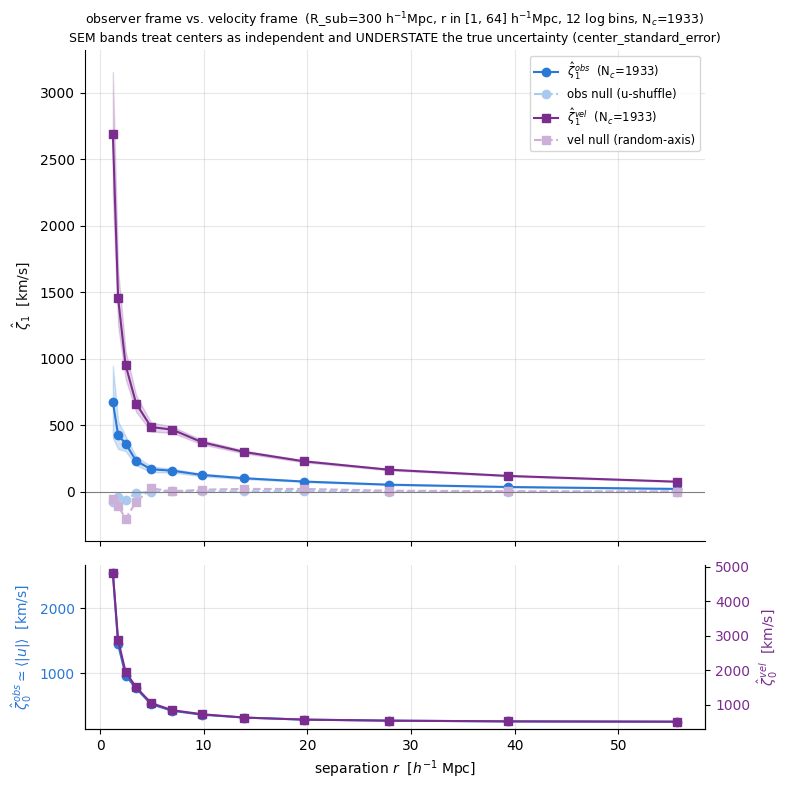

In [8]:
# The figure lives in this notebook's own cell output -- no PNG is written
# anywhere. Re-run the notebook to refresh it. The trailing bare `fig` of
# earlier versions is gone deliberately: `%matplotlib inline` already renders
# the figure at the end of the cell, so echoing it stored the same PNG twice.
fig = make_comparison_figure(cfg, results, comparison)

## 7 — Where does the gap between the frames come from?

δ_α = arccos(v̂_α · ẑ_α^obs) is the angle between the two frames' axes for each
center — the only place the observer enters the per-center bookkeeping, and a
pure diagnostic.

Because *both* axes follow the motion, δ_α is **capped at 90°**:

$$\cos\delta_\alpha \;=\; \hat v_\alpha \cdot \mathrm{sign}(u_\alpha)\hat n_{V,\alpha}
  \;=\; \frac{|u_\alpha|}{|\mathbf v_\alpha|} \;\ge\; 0$$

δ_α ≈ 0 means the two frames' axes coincide (the frame-agreement limit, reached
by any purely radial flow **in either direction**); δ_α ≈ 90° means the flow is
almost purely transverse — the case the observer frame is blind to entirely.
`velocity_frame_shell_dipole` enforces the ceiling rather than assuming it.

**Top panel** bins the per-center dipole difference (ζ̂₁^vel − ζ̂₁^obs, each
center's own curve shell-averaged) by δ_α:

- a **few high-δ_α centers driving the gap** ⇒ bulk-flow contamination;
- a **smooth spread** ⇒ genuine projection geometry.

**Bottom panel** is the δ_α histogram against the isotropic expectation. For
flow directions distributed isotropically about the line of sight, cos δ = |c|
with c uniform on [−1, 1], so P(δ) ∝ sin δ on [0, 90°] — the same functional
form as before, folded onto the half-range by the absolute value. An **excess at
low δ** relative to that reference means flow directions align with the lines of
sight — residual bulk motion of the sample.

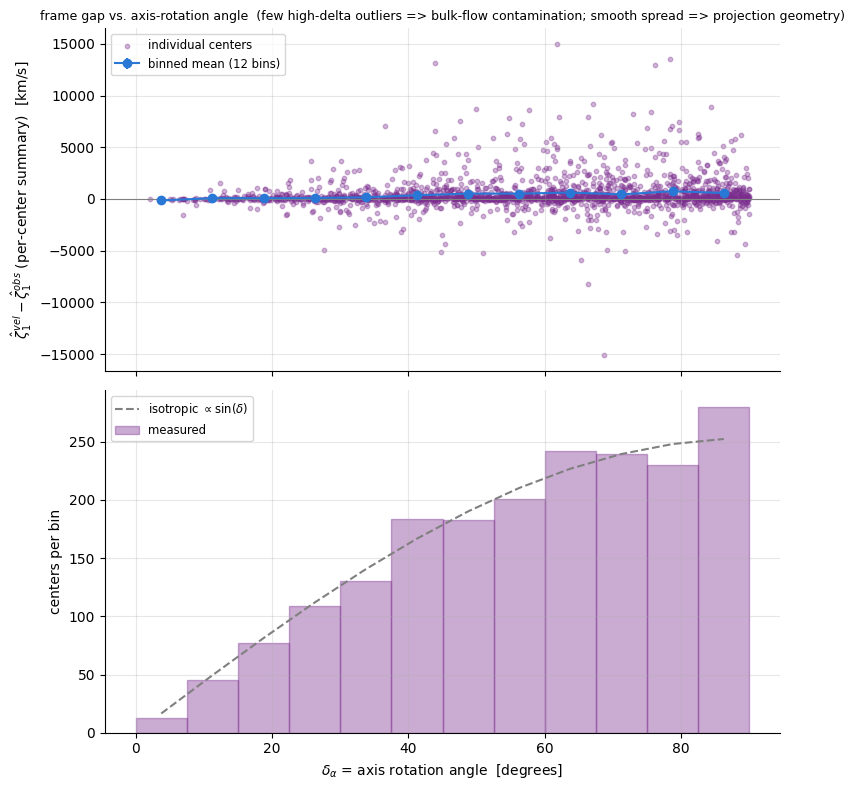

In [9]:
fig_angle = make_angle_diagnostic_figure(cfg, comparison)

## 8 — Summary numbers

A compact read-out of the comparison: the shell-averaged amplitude of each
frame, the ratio between them, and how far each null sits from zero in units of
its own SEM.

In [10]:
delta_deg = np.degrees(comparison.per_center_delta)

print(f"N_c = {centers.n_centers} centers, {len(comparison.shell_centers)} shells "
      f"({comparison.shell_centers[0]:.1f} - {comparison.shell_centers[-1]:.1f} h^-1 Mpc)")
print()
print(f"shell-averaged |zeta_hat|  obs : {np.abs(comparison.obs.zeta_hat).mean():8.2f} km/s")
print(f"shell-averaged |zeta_hat|  vel : {np.abs(comparison.vel.zeta_hat).mean():8.2f} km/s")
print(f"                     vel / obs : {np.abs(comparison.vel.zeta_hat).mean() / np.abs(comparison.obs.zeta_hat).mean():8.2f}")
print()
print(f"null / SEM  obs (u-shuffle)   : {np.nanmean(np.abs(comparison.obs.zeta_hat_shuffle) / comparison.obs.sem):8.2f}")
print(f"null / SEM  vel (random-axis) : {np.nanmean(np.abs(comparison.vel.zeta_hat_shuffle) / comparison.vel.sem):8.2f}")
print("   (both should be O(1) if the nulls are flat)")
print()
# The monopole panel, with halo clustering divided out. Both raw monopoles are
# (mean SPEED) x (occupancy ratio) -- both frames weight by a positive-definite
# speed now, |u_alpha| and |v_alpha| -- and that ratio IS 1 + xi_hh(r), so both
# decline from clustering alone. What is left after dividing it out is the
# genuine speed-density correlation, SHARED by the two frames.
occupancy = obs_result.pair_count / (obs_result.n_centers * expected_shell_occupancy(n_bar, obs_result.shell_edges))
nbar_v_b = expected_shell_occupancy(n_bar, obs_result.shell_edges)
print("occupancy ratio 1+xi_hh(r) :", np.round(occupancy, 3))
print()
obs_resid = comparison.obs.monopole_norm / occupancy
vel_resid = comparison.vel.monopole_norm / occupancy
print("monopole, raw               obs:", np.round(comparison.obs.monopole_norm, 1))
print("                            vel:", np.round(comparison.vel.monopole_norm, 1))
print("monopole / (1+xi_hh)        obs:", np.round(obs_resid, 1))
print("                            vel:", np.round(vel_resid, 1))
print(f"   residual change over the range   obs: {100*(obs_resid[-1]/obs_resid[0] - 1):+.1f}%   "
      f"vel: {100*(vel_resid[-1]/vel_resid[0] - 1):+.1f}%   <- SAME ~8% = speed-density correlation")
# Both asymptotes are mean SPEEDS: the axis carries the sign, so the weight is
# |u|, not u, and neither monopole is referenced to zero.
print(f"   asymptotes: <|u|> = {obs_result.per_center_speed.mean():.1f} km/s, "
      f"<|v|> = {vel_result.per_center_speed.mean():.1f} km/s")
print()
# The finite-distance (2r/3R) leakage is a SIGNED effect and is invisible in the
# speed-weighted monopole above -- |u| discards exactly the sign it lives in.
# per_center_u is retained (its sign is what flips z_hat), so the signed
# monopole that DOES carry the leakage is still recoverable, right here:
signed_monopole = (obs_result.per_center_u[:, None] * obs_result.per_center_count).sum(axis=0)
signed_monopole_norm = (signed_monopole / obs_result.n_centers) / nbar_v_b
print("SIGNED monopole  Sum u*N    obs:", np.round(signed_monopole_norm, 1))
print("        / (1+xi_hh)         obs:", np.round(signed_monopole_norm / occupancy, 1),
      "  <- TREND SURVIVES = (2r/3R) finite-distance leakage")
print(f"        asymptote: signed <u> = {obs_result.per_center_u.mean():.2f} km/s")
print()
# delta is capped at 90 deg by construction: cos(delta) = |u|/|v| >= 0, since
# BOTH frames' axes follow the motion (conventions.VELOCITY_AXIS_CONVENTION).
print(f"delta_alpha : median {np.median(delta_deg):.1f} deg, "
      f"{(delta_deg < 30).sum()} centers below 30 deg, "
      f"max {delta_deg.max():.1f} deg (ceiling 90)")
print(f"per-center dipole difference : mean {comparison.per_center_dipole_difference.mean():+.2f} km/s")

N_c = 1933 centers, 12 shells (1.2 - 54.6 h^-1 Mpc)

shell-averaged |zeta_hat|  obs :   202.80 km/s
shell-averaged |zeta_hat|  vel :   664.43 km/s
                     vel / obs :     3.28

null / SEM  obs (u-shuffle)   :     0.54
null / SEM  vel (random-axis) :     1.13
   (both should be O(1) if the nulls are flat)

occupancy ratio 1+xi_hh(r) : [8.58  5.149 3.596 2.748 1.911 1.534 1.33  1.175 1.085 1.041 1.011 1.006]

monopole, raw               obs: [2547.9 1444.9  963.3  764.5  521.7  419.4  358.8  314.6  283.4  267.8
  256.5  251.7]
                            vel: [4817.9 2867.5 1947.4 1502.8 1046.3  839.9  722.   626.4  566.5  536.9
  514.8  506.8]
monopole / (1+xi_hh)        obs: [297.  280.6 267.9 278.2 273.  273.4 269.8 267.7 261.3 257.4 253.7 250.3]
                            vel: [561.5 556.9 541.6 546.9 547.6 547.4 543.  533.1 522.3 515.9 509.3 503.9]
   residual change over the range   obs: -15.7%   vel: -10.3%   <- SAME ~8% = speed-density correlation
   asymptotes: <|u